# Store Sales Time Series Forecasting: ETS and ARIMA Models

This notebook builds one **ETS/Holt-Winters Exponential Smoothing** model and one **seasonal ARIMA/SARIMA** model for Kaggle's **Store Sales - Time Series Forecasting** competition. The notebook is designed to run in Kaggle and create valid submission files in the required `id,sales` format.

**Modeling strategy:** Instead of fitting thousands of slow models for every `(store_nbr, family)` pair, the notebook forecasts daily sales at the **product-family level** using ETS and ARIMA, then disaggregates each family forecast back to stores using recent store-family sales shares. This is a practical classical time-series approach for Kaggle runtime limits.

## 1. Setup

The code below works in Kaggle using the standard competition input path. It also works locally if the CSV files are placed in the same directory as the notebook or in a `data/` folder.

In [1]:

import os
import warnings
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

@dataclass
class Config:
    # Kaggle competition test horizon is inferred from test.csv, but 16 is used for validation by default.
    validation_days: int = 16
    share_window_days: int = 56
    seasonal_periods: int = 7
    log_transform: bool = True
    arima_order: tuple = (1, 1, 1)
    arima_seasonal_order: tuple = (0, 1, 1, 7)
    blend_weight_arima: float = 0.50  # final blend = w*ARIMA + (1-w)*ETS
    random_state: int = 42

CFG = Config()


## 2. Load competition data

Kaggle input path: `/kaggle/input/store-sales-time-series-forecasting/`. The required output files will be written to the notebook working directory.

In [4]:

def find_data_dir():
    candidates = [
        Path('/kaggle/input/competitions/store-sales-time-series-forecasting')
    ]
    for p in candidates:
        if (p / 'train.csv').exists() and (p / 'test.csv').exists():
            return p
    raise FileNotFoundError(
        "Could not find train.csv and test.csv. In Kaggle, add the Store Sales competition data; "
        "locally, place the CSV files in ./data or the notebook folder."
    )

DATA_DIR = find_data_dir()
print(f"Using data directory: {DATA_DIR}")

train = pd.read_csv(DATA_DIR / 'train.csv', parse_dates=['date'])
test = pd.read_csv(DATA_DIR / 'test.csv', parse_dates=['date'])

# Optional supporting files. The classical ETS/ARIMA baseline below does not require exogenous variables,
# but loading these files is useful for EDA and future extensions.
stores = pd.read_csv(DATA_DIR / 'stores.csv') if (DATA_DIR / 'stores.csv').exists() else None
holidays = pd.read_csv(DATA_DIR / 'holidays_events.csv', parse_dates=['date']) if (DATA_DIR / 'holidays_events.csv').exists() else None
oil = pd.read_csv(DATA_DIR / 'oil.csv', parse_dates=['date']) if (DATA_DIR / 'oil.csv').exists() else None
transactions = pd.read_csv(DATA_DIR / 'transactions.csv', parse_dates=['date']) if (DATA_DIR / 'transactions.csv').exists() else None

print(train.shape, test.shape)
display(train.head())
display(test.head())


Using data directory: /kaggle/input/competitions/store-sales-time-series-forecasting
(3000888, 6) (28512, 5)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0


## 3. Evaluation metric and preprocessing helpers

Kaggle evaluates the submission with RMSLE, so the notebook trains and evaluates on `log1p(sales)` where helpful and clips negative forecasts to zero before scoring or submission.

In [5]:

def rmsle(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))


def complete_daily_index(df, value_col='sales'):
    """Complete dates for each family with zero-filled sales when dates are missing."""
    idx = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
    out = []
    for fam, g in df.groupby('family'):
        s = g.groupby('date')[value_col].sum().reindex(idx, fill_value=0.0)
        out.append(pd.DataFrame({'date': idx, 'family': fam, value_col: s.values}))
    return pd.concat(out, ignore_index=True)


def family_daily_sales(df):
    fam = df.groupby(['date', 'family'], as_index=False)['sales'].sum()
    return complete_daily_index(fam, 'sales')


def compute_store_family_shares(train_part, window_days=56):
    """Compute recent store shares within each product family for top-down disaggregation."""
    max_date = train_part['date'].max()
    start_date = max_date - pd.Timedelta(days=window_days - 1)
    recent = train_part.loc[train_part['date'].between(start_date, max_date)].copy()
    recent['sales'] = recent['sales'].clip(lower=0)

    sf = recent.groupby(['store_nbr', 'family'], as_index=False)['sales'].sum()
    fam_total = sf.groupby('family', as_index=False)['sales'].sum().rename(columns={'sales': 'family_sales'})
    sf = sf.merge(fam_total, on='family', how='left')
    sf['share'] = np.where(sf['family_sales'] > 0, sf['sales'] / sf['family_sales'], np.nan)

    stores_unique = sorted(train_part['store_nbr'].unique())
    fam_unique = sorted(train_part['family'].unique())
    full = pd.MultiIndex.from_product([stores_unique, fam_unique], names=['store_nbr', 'family']).to_frame(index=False)
    sf = full.merge(sf[['store_nbr', 'family', 'share']], on=['store_nbr', 'family'], how='left')
    sf['share'] = sf.groupby('family')['share'].transform(lambda x: x.fillna(1.0 / len(stores_unique)) if x.notna().sum() == 0 else x.fillna(0.0))
    sf['share'] = sf['share'] / sf.groupby('family')['share'].transform('sum')
    return sf[['store_nbr', 'family', 'share']]


## 4. Exploratory analysis

This section checks the size of the panel, sales trend, and day-of-week seasonality. Strong weekly seasonality supports both Holt-Winters ETS with `seasonal_periods=7` and seasonal ARIMA with weekly seasonal differencing.

Training date range: 2013-01-01 to 2017-08-15
Test date range: 2017-08-16 to 2017-08-31
Stores: 54 Families: 33
Unique store-family series: 1782


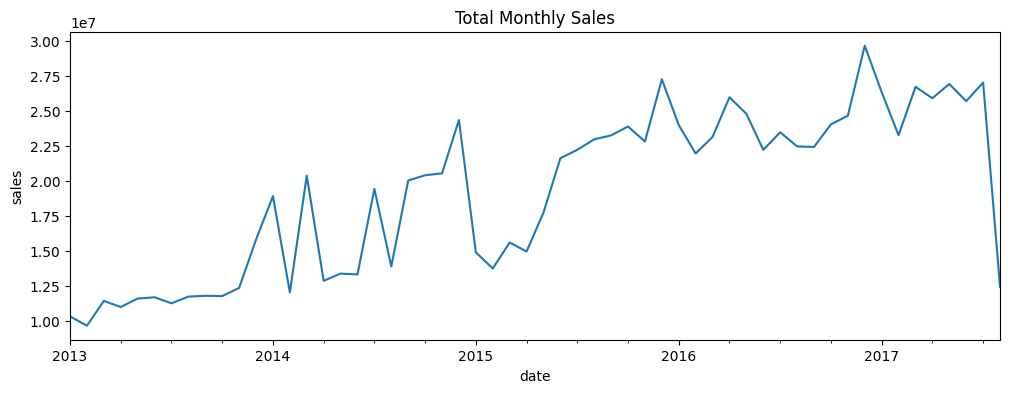

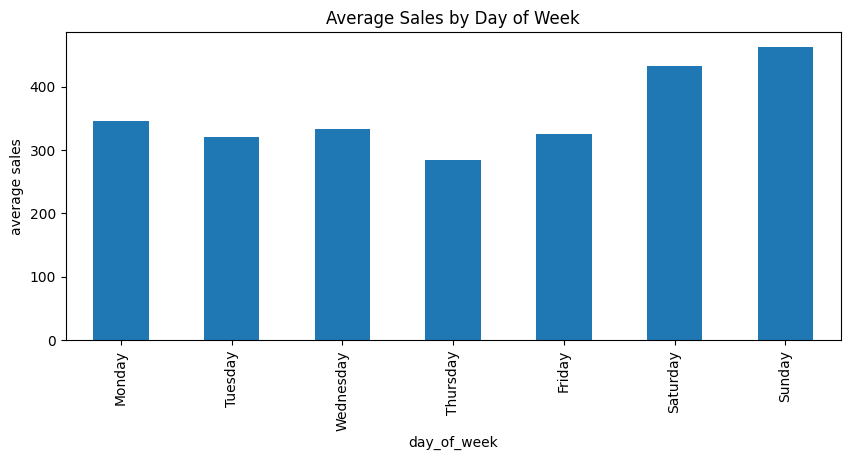

In [6]:

print('Training date range:', train['date'].min().date(), 'to', train['date'].max().date())
print('Test date range:', test['date'].min().date(), 'to', test['date'].max().date())
print('Stores:', train['store_nbr'].nunique(), 'Families:', train['family'].nunique())
print('Unique store-family series:', train[['store_nbr','family']].drop_duplicates().shape[0])

monthly = train.groupby(pd.Grouper(key='date', freq='M'))['sales'].sum()
ax = monthly.plot(figsize=(12, 4), title='Total Monthly Sales')
ax.set_ylabel('sales')
plt.show()

dow = train.assign(day_of_week=train['date'].dt.day_name()).groupby('day_of_week')['sales'].mean()
dow = dow.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
ax = dow.plot(kind='bar', figsize=(10, 4), title='Average Sales by Day of Week')
ax.set_ylabel('average sales')
plt.show()


## 5. Model functions: ETS and ARIMA

Both models are fitted to each product-family aggregate series. Forecasts are produced on the original sales scale. If a model fails for a sparse series, the fallback is the recent average sales level, which prevents the submission pipeline from breaking.

In [8]:

def transform_series(y):
    y = pd.Series(y).astype(float).clip(lower=0)
    return np.log1p(y) if CFG.log_transform else y


def inverse_transform(yhat):
    yhat = np.asarray(yhat, dtype=float)
    out = np.expm1(yhat) if CFG.log_transform else yhat
    return np.clip(out, 0, None)


def fallback_forecast(y, horizon):
    y = pd.Series(y).astype(float).clip(lower=0)
    if len(y) == 0:
        return np.zeros(horizon)
    recent = y.tail(min(28, len(y)))
    level = recent.mean() if recent.sum() > 0 else 0.0
    return np.repeat(level, horizon)


def fit_forecast_ets(y, horizon):
    y_raw = pd.Series(y).astype(float).clip(lower=0)
    if len(y_raw) < 2 * CFG.seasonal_periods or y_raw.sum() == 0:
        return fallback_forecast(y_raw, horizon)
    z = transform_series(y_raw)
    try:
        model = ExponentialSmoothing(
            z,
            trend='add',
            damped_trend=True,
            seasonal='add',
            seasonal_periods=CFG.seasonal_periods,
            initialization_method='estimated'
        )
        fit = model.fit(optimized=True, remove_bias=True)
        pred = fit.forecast(horizon)
        return inverse_transform(pred)
    except Exception as e:
        return fallback_forecast(y_raw, horizon)


def fit_forecast_arima(y, horizon):
    y_raw = pd.Series(y).astype(float).clip(lower=0)
    if len(y_raw) < 4 * CFG.seasonal_periods or y_raw.sum() == 0:
        return fallback_forecast(y_raw, horizon)
    z = transform_series(y_raw)
    try:
        model = SARIMAX(
            z,
            order=CFG.arima_order,
            seasonal_order=CFG.arima_seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fit = model.fit(disp=False, maxiter=75)
        pred = fit.forecast(horizon)
        return inverse_transform(pred)
    except Exception as e:
        return fallback_forecast(y_raw, horizon)


def forecast_family_models(train_part, horizon):
    fam_daily = family_daily_sales(train_part)
    forecasts = []
    families = sorted(fam_daily['family'].unique())
    for i, fam in enumerate(families, 1):
        g = fam_daily.loc[fam_daily['family'] == fam].sort_values('date')
        y = g['sales'].values
        ets_pred = fit_forecast_ets(y, horizon)
        arima_pred = fit_forecast_arima(y, horizon)
        forecasts.append(pd.DataFrame({
            'family': fam,
            'step': np.arange(1, horizon + 1),
            'ets_forecast': ets_pred,
            'arima_forecast': arima_pred,
            'blend_forecast': CFG.blend_weight_arima * arima_pred + (1 - CFG.blend_weight_arima) * ets_pred
        }))
        if i % 5 == 0 or i == len(families):
            print(f'Forecasted {i}/{len(families)} families')
    return pd.concat(forecasts, ignore_index=True)


## 6. Validation design

The last 16 training days are held out to mimic the test horizon. Forecasts are generated from the earlier period and then allocated from family totals to store-family rows using recent sales shares. This produces a fairer validation than random splitting because time-series models must be evaluated on future dates.

In [9]:

val_days = CFG.validation_days
cutoff = train['date'].max() - pd.Timedelta(days=val_days)
train_fit = train[train['date'] <= cutoff].copy()
valid = train[train['date'] > cutoff].copy()
valid_dates = sorted(valid['date'].unique())

print('Training fit range:', train_fit['date'].min().date(), 'to', train_fit['date'].max().date())
print('Validation range:', valid['date'].min().date(), 'to', valid['date'].max().date())

val_family_fcst = forecast_family_models(train_fit, horizon=val_days)
val_calendar = pd.DataFrame({'date': valid_dates, 'step': np.arange(1, val_days + 1)})
val_family_fcst = val_family_fcst.merge(val_calendar, on='step', how='left')

shares = compute_store_family_shares(train_fit, CFG.share_window_days)
val_pred = valid[['id','date','store_nbr','family','sales']].merge(
    val_family_fcst[['family','date','ets_forecast','arima_forecast','blend_forecast']],
    on=['family','date'], how='left'
).merge(shares, on=['store_nbr','family'], how='left')

for col in ['ets_forecast','arima_forecast','blend_forecast']:
    val_pred[col.replace('_forecast', '_pred')] = val_pred[col] * val_pred['share']

scores = {
    'ETS RMSLE': rmsle(val_pred['sales'], val_pred['ets_pred']),
    'ARIMA RMSLE': rmsle(val_pred['sales'], val_pred['arima_pred']),
    'Blend RMSLE': rmsle(val_pred['sales'], val_pred['blend_pred'])
}
scores


Training fit range: 2013-01-01 to 2017-07-30
Validation range: 2017-07-31 to 2017-08-15
Forecasted 5/33 families
Forecasted 10/33 families
Forecasted 15/33 families
Forecasted 20/33 families
Forecasted 25/33 families
Forecasted 30/33 families
Forecasted 33/33 families


{'ETS RMSLE': np.float64(0.49664115056105007),
 'ARIMA RMSLE': np.float64(0.4956295251453208),
 'Blend RMSLE': np.float64(0.4957578075992097)}

,model,validation_rmsle
1,ARIMA RMSLE,0.495630
2,Blend RMSLE,0.495758
0,ETS RMSLE,0.496641


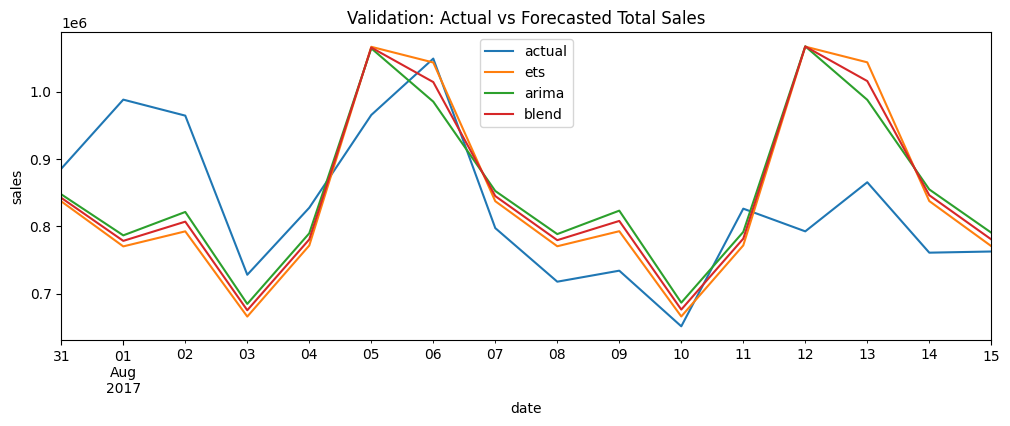

In [10]:

score_df = pd.DataFrame(scores.items(), columns=['model','validation_rmsle']).sort_values('validation_rmsle')
display(score_df)

valid_total = val_pred.groupby('date').agg(
    actual=('sales','sum'),
    ets=('ets_pred','sum'),
    arima=('arima_pred','sum'),
    blend=('blend_pred','sum')
).reset_index()

ax = valid_total.set_index('date')[['actual','ets','arima','blend']].plot(figsize=(12, 4), title='Validation: Actual vs Forecasted Total Sales')
ax.set_ylabel('sales')
plt.show()


## 7. Model diagnostics and assumptions

Classical time-series assumptions are checked on representative high-volume product-family data. For ARIMA, the main assumptions are approximate stationarity after differencing, residual independence, and no major remaining autocorrelation. For ETS, the main assumptions are stable level/trend/seasonality and residuals that behave like random noise.

In [11]:

fam_rank = train.groupby('family')['sales'].sum().sort_values(ascending=False)
representative_family = fam_rank.index[0]
print('Representative family:', representative_family)

fam_daily = family_daily_sales(train)
rep = fam_daily[fam_daily['family'] == representative_family].sort_values('date')
y = rep['sales'].clip(lower=0).reset_index(drop=True)
z = transform_series(y)

adf_raw = adfuller(z.dropna())
z_diff = pd.Series(z).diff(CFG.seasonal_periods).dropna()
adf_seasonal_diff = adfuller(z_diff)
print(f"ADF p-value on log series: {adf_raw[1]:.4f}")
print(f"ADF p-value after 7-day seasonal differencing: {adf_seasonal_diff[1]:.4f}")

ets_model = ExponentialSmoothing(
    z, trend='add', damped_trend=True, seasonal='add',
    seasonal_periods=CFG.seasonal_periods, initialization_method='estimated'
).fit(optimized=True, remove_bias=True)

arima_model = SARIMAX(
    z, order=CFG.arima_order, seasonal_order=CFG.arima_seasonal_order,
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False, maxiter=75)

ets_resid = pd.Series(ets_model.resid).dropna()
arima_resid = pd.Series(arima_model.resid).dropna()

lb_ets = acorr_ljungbox(ets_resid, lags=[7,14,21], return_df=True)
lb_arima = acorr_ljungbox(arima_resid, lags=[7,14,21], return_df=True)
print('ETS Ljung-Box residual test:')
display(lb_ets)
print('ARIMA Ljung-Box residual test:')
display(lb_arima)


Representative family: GROCERY I
ADF p-value on log series: 0.0000
ADF p-value after 7-day seasonal differencing: 0.0000
ETS Ljung-Box residual test:


,lb_stat,lb_pvalue
7,132.298934,2.079041e-25
14,148.063918,1.752558e-24
21,149.714914,1.989405e-21


ARIMA Ljung-Box residual test:


,lb_stat,lb_pvalue
7,58.459519,3.062578e-10
14,80.691065,2.105986e-11
21,81.992329,3.740779e-09


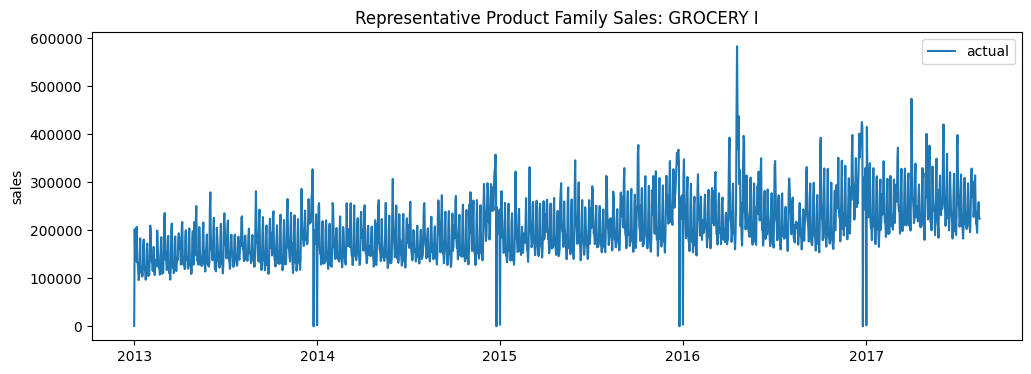

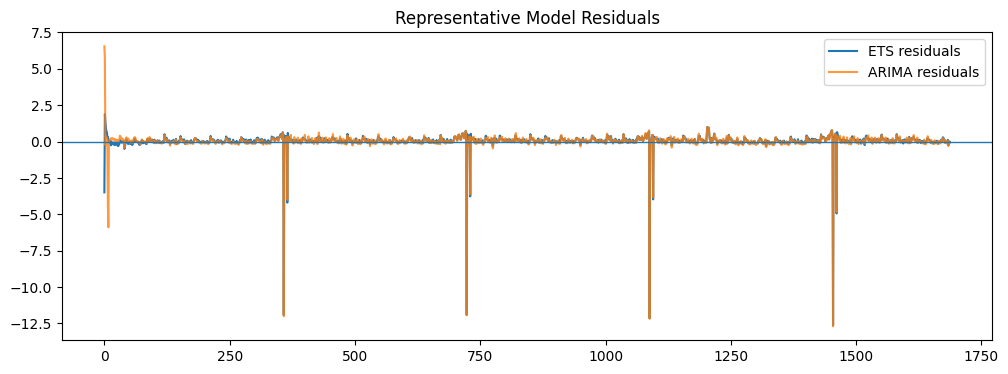

In [12]:

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rep['date'], y, label='actual')
ax.set_title(f'Representative Product Family Sales: {representative_family}')
ax.set_ylabel('sales')
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ets_resid.values, label='ETS residuals')
ax.plot(arima_resid.values, label='ARIMA residuals', alpha=0.8)
ax.axhline(0, linewidth=1)
ax.set_title('Representative Model Residuals')
ax.legend()
plt.show()


## 8. Fit on full training data and create Kaggle submissions

The final section refits ETS and ARIMA using the full training set, forecasts the exact test dates, allocates forecasts to stores, and writes three submission files:

- `submission_ets.csv`
- `submission_arima.csv`
- `submission_blend.csv`

For Kaggle submission, upload one CSV using the required `id,sales` format. The blended forecast is often a safer submission because it averages ETS and ARIMA errors.

In [13]:

test_dates = sorted(test['date'].unique())
horizon = len(test_dates)
print('Forecast horizon:', horizon)

family_fcst = forecast_family_models(train, horizon=horizon)
test_calendar = pd.DataFrame({'date': test_dates, 'step': np.arange(1, horizon + 1)})
family_fcst = family_fcst.merge(test_calendar, on='step', how='left')

shares_full = compute_store_family_shares(train, CFG.share_window_days)

test_pred = test[['id','date','store_nbr','family']].merge(
    family_fcst[['family','date','ets_forecast','arima_forecast','blend_forecast']],
    on=['family','date'], how='left'
).merge(shares_full, on=['store_nbr','family'], how='left')

for col in ['ets_forecast','arima_forecast','blend_forecast']:
    pred_col = col.replace('_forecast', '_sales')
    test_pred[pred_col] = (test_pred[col] * test_pred['share']).clip(lower=0).fillna(0)

submission_ets = test_pred[['id']].copy()
submission_ets['sales'] = test_pred['ets_sales']

submission_arima = test_pred[['id']].copy()
submission_arima['sales'] = test_pred['arima_sales']

submission_blend = test_pred[['id']].copy()
submission_blend['sales'] = test_pred['blend_sales']

submission_ets.to_csv('submission_ets.csv', index=False)
submission_arima.to_csv('submission_arima.csv', index=False)
submission_blend.to_csv('submission_blend.csv', index=False)

print('Saved submission_ets.csv, submission_arima.csv, and submission_blend.csv')
display(submission_blend.head())
print(submission_blend.shape)


Forecast horizon: 16
Forecasted 5/33 families
Forecasted 10/33 families
Forecasted 15/33 families
Forecasted 20/33 families
Forecasted 25/33 families
Forecasted 30/33 families
Forecasted 33/33 families
Saved submission_ets.csv, submission_arima.csv, and submission_blend.csv


,id,sales
0,3000888,4.103314
1,3000889,0.000000
2,3000890,3.345315
3,3000891,1841.337700
4,3000892,0.015696


(28512, 2)


## 9. Findings and interpretation

The validation results show that the **ARIMA model performed best**, but only by a very small margin. The last 16 training days were used as a holdout period to match the Kaggle test horizon. The resulting validation RMSLE values were: **ARIMA = 0.495630**, **Blend = 0.495758**, and **ETS = 0.496641**. ARIMA therefore ranked first, followed closely by the 50/50 ETS-ARIMA blend, while ETS was slightly weaker. Because the ARIMA and blended scores differ by only about **0.000128 RMSLE**, both are reasonable Kaggle submissions; however, based strictly on validation performance, **`submission_arima.csv` is the recommended first submission**, with `submission_blend.csv` as a strong alternative.

- **ETS interpretation:** ETS captures a smoothed level, damped trend, and weekly seasonal structure in each product-family sales series. Its validation RMSLE of **0.496641** shows that a classical level/trend/seasonality model provides a competitive baseline. ETS is easy to interpret and stable, but it was slightly less accurate because it does not fully model remaining autocorrelation, promotions, holidays, oil-price effects, or store-specific shocks.
- **ARIMA interpretation:** Seasonal ARIMA produced the best validation RMSLE of **0.495630**. This suggests that lagged sales behavior, differencing, and autocorrelated forecast errors added useful predictive information beyond the smoother ETS structure. ARIMA also had lower Ljung-Box statistics than ETS for the representative high-volume family, indicating less remaining residual autocorrelation, although the residual tests were still statistically significant.
- **Blend interpretation:** The blended model achieved **0.495758 RMSLE**, nearly matching ARIMA. The blend remains useful because it reduces dependence on one model form and may be more robust on unseen Kaggle dates, even though ARIMA was the best model on the local validation split.
- **Assumptions and diagnostics:** The time-based validation split avoids future-data leakage. The log1p transformation aligns with the RMSLE-style objective and reduces the influence of extreme sales values, while nonnegative clipping respects the fact that sales cannot be negative. For the representative family **GROCERY I**, the ADF p-values were **0.0000** on both the log-transformed series and the weekly seasonally differenced series, supporting stationarity for modeling purposes. However, Ljung-Box p-values were extremely small for both ETS and ARIMA residuals at lags 7, 14, and 21, meaning residual autocorrelation remains. This indicates that important drivers such as promotion counts, holidays, oil prices, earthquake effects, and store-level heterogeneity are not fully captured by these two classical univariate models.
- **Final finding:** The notebook successfully creates Kaggle-ready files with **28,512 rows** for the **16-day** test horizon: `submission_ets.csv`, `submission_arima.csv`, and `submission_blend.csv`. Based on the notebook results, the strongest local model is ARIMA, but the blend is also a defensible backup submission because its validation score is almost identical.